# Google Drive

In [ ]:
# # G D R I V E
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


# Installations

In [ ]:
# BioPython (Data Gathering)
!pip install biopython
!pip install --upgrade biopython
# NLP
import nltk
nltk.download('stopwords')
nltk.download('punkt') #this is the corpus with linguistic categories, i.e. nouns = NN
nltk.download('averaged_perceptron_tagger')
# tmtoolkit (LDA Evaluation)
"""
!pip install -U tmtoolkit[recommended,lda,sklearn,gensim]
!python -m tmtoolkit setup en,de
!sudo apt install libgmp-dev libmpfr-dev libmpc-dev
!pip install gmpy2
"""

     |████████████████████████████████| 2.3 MB 33.7 MB/s 
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


'\n!pip install -U tmtoolkit[recommended,lda,sklearn,gensim]\n!python -m tmtoolkit setup en,de\n!sudo apt install libgmp-dev libmpfr-dev libmpc-dev\n!pip install gmpy2\n'

In [ ]:
# # L I B R A R I E S 
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import math
import collections
from collections import Counter
import re
import string
import time
import json
from urllib.error import HTTPError
import os, glob
# NLP
import nltk
from nltk import word_tokenize, pos_tag
from nltk.corpus import stopwords
import sklearn as sk
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer 
from sklearn.decomposition import NMF, LatentDirichletAllocation
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction import text
"""
import tmtoolkit
from tmtoolkit.topicmod import tm_lda
from tmtoolkit.topicmod.tm_lda import evaluate_topic_models
from tmtoolkit.topicmod.evaluate import results_by_parameter
from tmtoolkit.topicmod.visualize import plot_eval_results
"""
from scipy.stats import entropy
from scipy.sparse import lil_matrix
from scipy.spatial import distance
from gensim.models import ldamodel
from gensim.matutils import jensen_shannon
try:
    import cPickle as pickle
except ModuleNotFoundError:
    import pickle
from Bio import Entrez
from Bio import Medline

In [ ]:
print(.__version__)

SyntaxError: ignored

# Data Gathering with Entrez

In [ ]:
# # F U N C T I O N S
year = '2020'
def search(query):
    Entrez.email = 'sofia.aguilarv@alumnos.udg.mx'
    handle = Entrez.esearch(db='pubmed',
                            sort='relevance',
                            retmax=10**5,
                            retmode='xml',
                            maxdate=year,
                            term=query)
    results = Entrez.read(handle)
    return results

def fetch_details(id_list):
    ids = ','.join(id_list)
    Entrez.email = 'sofia.aguilarv@alumnos.udg.mx'
    handle = Entrez.efetch(db='pubmed',
                           retmode='xml',
                           id=ids)
    results = Entrez.read(handle)
    return results

In [ ]:
# # E X T R A C T I O N
concept = 'connectomics'
paper_abstract = []
paper_title = [] 
paper_id = []
paper_year = []

if __name__ == '__main__':
  results = search(concept)
  id_list = results['IdList']
  papers = fetch_details(id_list)
  for i, paper in enumerate(papers['PubmedArticle']):
    try:
      paper_abstract.append(paper['MedlineCitation']['Article']['Abstract']['AbstractText'])
      paper_title.append(paper['MedlineCitation']['Article']['ArticleTitle'])
      paper_id.append(paper['MedlineCitation']['PMID'])
      paper_year.append(paper['PubmedData']['History'][0]['Year'])
    except:
      None

In [ ]:
# Check size of each list
print(len(paper_abstract))
print(len(paper_title))
print(len(paper_id))
print(len(paper_year))

In [ ]:
# Generate Pandas DataFrame from list of dictionaries
dictionary = {'pubmed_id': paper_id, 'title': paper_title, \
              'abstract': paper_abstract, 'publication_year': paper_year}
Data_Frame = pd.DataFrame.from_dict(dictionary)

# Data Cleaning

In [ ]:
# # F U N C T I O N
emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"  # emoticons
                               u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                               u"\U0001F680-\U0001F6FF"  # transport & map symbols
                               u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                               u"\U00002500-\U00002BEF"  # chinese char
                               u"\U00002702-\U000027B0"
                               u"\U00002702-\U000027B0"
                               u"\U000024C2-\U0001F251"
                               u"\U0001f926-\U0001f937"
                               u"\U00010000-\U0010ffff"
                               u"\u2640-\u2642"
                               u"\u2600-\u2B55"
                               u"\u200d"
                               u"\u23cf"
                               u"\u23e9"
                               u"\u231a"
                               u"\ufe0f"  # dingbats
                               u"\u3030"
                               "]+", flags=re.UNICODE)

def clean_text_round1(text):
    '''Make text lowercase, remove text in square brackets and parentheses, remove punctuation, remove words containing numbers and \n.'''
    text = ([each_text.lower() for each_text in text])
    text = re.sub('<\/?[bi]>', '', str(text)) # Removes bold and italic tags
    text = re.sub('[‘’“”…]', '', str(text))
    text = re.sub('-', '', str(text)) # Compound words become one word
    text = re.sub('[%s]' % re.escape(string.punctuation), '', str(text))
    text = re.sub('\n', '', str(text))
    text = re.sub('\r', '', str(text))
    text = re.sub('\ri', '', str(text))
    text = emoji_pattern.sub(r'', str(text)) # Removes emojis
    text = emoji_pattern.sub(r'', str(text)) # Removes emojis
    return text

In [ ]:
for k in range(0, len(Data_Frame.abstract)):
  Data_Frame.abstract[k] = clean_text_round1(Data_Frame.abstract[k])

# Stopwords removal

In [ ]:
# Data import
filename = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Metadata/Metadata_2020.csv"
Data_Frame = pd.read_csv(filename,index_col=0)
Data_Frame

,pubmed_id,title,abstract,abstract_without_stopwords,publication_year
0,29784759,Of what use is connectomics? A personal perspe...,the brain is a network of neurons and its biol...,brain neurons biological output behaviour exci...,2018
1,31256864,Connectomics in Brain Malformations: How Is th...,a new neuroimaging dimension is currently bein...,new neuroimaging dimension currently adopted s...,2019
2,30268923,The emergent connectome in Caenorhabditis eleg...,the relatively new field of connectomics provi...,relatively new field provides unique window ne...,2018
3,31703899,The human connectome from an evolutionary pers...,the connectome describes the comprehensive set...,connectome describes comprehensive set neurona...,2019
4,29962025,Static and dynamic connectomics differentiate ...,neural circuit dysfunction underlies the biolo...,neural circuit dysfunction underlies biologica...,2017
...,...,...,...,...,...
6077,24989351,Brain network informed subject community detec...,earlyonset schizophrenia eos offers a unique o...,earlyonset schizophrenia eos offers unique opp...,2014
6078,24860494,Tai Chi Chuan optimizes the functional organiz...,whether tai chi chuan tcc can influence the in...,tai chi chuan tcc influence intrinsic function...,2014
6079,24719857,Surface-based regional homogeneity in first-ep...,previous volumebased regional homogeneity reho...,previous volumebased regional homogeneity reho...,2013
6080,23585869,Can Taichi reshape the brain? A brain morphome...,although research has provided abundant eviden...,research provided abundant evidence taichiindu...,2012


In [ ]:
# Directories
folder_path = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Metadata"
metadata_filenames = os.listdir(folder_path)
metadata_filenames = [x for x in metadata_filenames if ".ipynb_checkpoints" not in x]
metadata_filenames.sort(key=lambda x: int(''.join(filter(str.isdigit, x))))
metadata_filenames

['Metadata_2005.csv',
 'Metadata_2008.csv',
 'Metadata_2009.csv',
 'Metadata_2010.csv',
 'Metadata_2011.csv',
 'Metadata_2012.csv',
 'Metadata_2013.csv',
 'Metadata_2014.csv',
 'Metadata_2015.csv',
 'Metadata_2016.csv',
 'Metadata_2017.csv',
 'Metadata_2018.csv',
 'Metadata_2019.csv',
 'Metadata_2020.csv',
 'Metadata_2021_raw.csv',
 'Metadata_2021.csv']

In [ ]:
# Get DTM for each metadata
cv = CountVectorizer()
approach = "abstract_without_stopwords"
Path_results = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Words_Frequency_Results/Without_Stopwords/"
year_list = [2005,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020]
for index in range(0,len(metadata_filenames)-2):
  filename = folder_path + "/" + metadata_filenames[index]
  #print(filename)
  year = year_list[index]
  #print(year)
  Data_Frame = pd.read_csv(filename,index_col=0)
  matrix = cv.fit_transform(Data_Frame[approach]) # sparse matrix
  print("Year "+str(year)+" DTM shape is: "+str(matrix.shape))
  # Save objects
  open_file = open(Path_results + str(year) + "_Words_Frequency.pkl", "wb")
  pickle.dump(matrix, open_file)
  open_file.close()
#words = cv.get_feature_names()
#freq = matrix.sum(axis=0).tolist()[0]
#freq_matrix = list(zip(words, freq))    
# sort from largest to smallest
#print(sorted(freqs, key=lambda x: -x[1]))

Year 2005 DTM shape is: (1, 41)
Year 2008 DTM shape is: (4, 210)
Year 2009 DTM shape is: (14, 855)
Year 2010 DTM shape is: (44, 2004)
Year 2011 DTM shape is: (117, 3625)
Year 2012 DTM shape is: (283, 6412)
Year 2013 DTM shape is: (685, 10132)
Year 2014 DTM shape is: (1190, 13627)
Year 2015 DTM shape is: (1838, 17625)
Year 2016 DTM shape is: (2617, 21861)
Year 2017 DTM shape is: (3555, 26419)
Year 2018 DTM shape is: (4687, 31455)
Year 2019 DTM shape is: (5608, 35422)
Year 2020 DTM shape is: (6082, 37399)


In [ ]:
DF = pd.DataFrame(freq_matrix, columns=["Words","Frequency"])
DF.sort_values(by="Frequency",axis=0,inplace=True,ascending=False)
DF.reset_index(inplace=True,drop=True)
print(DF.loc[DF["Words"]=="connect"])
DF

        Words  Frequency
1935  connect         78


,Words,Frequency
0,the,69011
1,of,48719
2,and,46828
3,in,35469
4,to,26166
...,...,...
37678,parahippocampalentorhinal,1
37679,parahippocampalhippocampal,1
37680,parahippocampalretrosplenial,1
37681,parahippocampi,1


In [ ]:
# Stopwords removal
cv = CountVectorizer()
concept = 'connectomics'
stop_scikit = text.ENGLISH_STOP_WORDS.union([concept,\
              "function","network","connect"]) # add words to stopwords list
#Data_Frame['abstract_without_stopwords'] = Data_Frame['abstract'].apply(lambda x:\
#              ' '.join([word for word in x.split() if word not in (stop_scikit)]))

In [ ]:
len(stop_scikit)

322

In [ ]:
DF = pd.DataFrame(stop_scikit, columns=["Stopwords"])
DF.sort_values("Stopwords", inplace=True)
DF.reset_index(inplace=True, drop=True)
DF.to_csv("Stopwords_List.csv")

In [ ]:
# Rearrange dataframe keys
Data_Frame = Data_Frame[['pubmed_id','title','abstract',\
                         'abstract_without_stopwords','publication_year']]

# Filter by year

In [ ]:
Data_Frame.loc[(Data_Frame['publication_year'] == 2014)]

,pubmed_id,title,abstract,abstract_without_stopwords,publication_year


In [ ]:
remove_years = ['2021','2020','2019','2018','2017','2016','2015','2014','2013',\
                '2012','2011','2010','2009','2008']
Data_Frame = Data_Frame[~Data_Frame['publication_year'].isin(remove_years)] # Drops rows with those years
# Reset index enumeration
Data_Frame.reset_index(drop=True, inplace=True)
Data_Frame

,pubmed_id,title,abstract,abstract_without_stopwords,publication_year
0,16201007,The human connectome: A structural description...,the connection matrix of the human brain the h...,connection matrix human brain human connectome...,2005


In [ ]:
Data_Frame.to_csv('Metadata_2005.csv')

# Data Import

In [ ]:
Data_Frame = pd.read_csv("/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Metadata/Metadata_2005.csv", index_col=0)
Data_Frame

,pubmed_id,title,abstract,abstract_without_stopwords,publication_year
0,16201007,The human connectome: A structural description...,the connection matrix of the human brain the h...,connection matrix human brain human connectome...,2005


---
# With Stopwords


---


# Run LDA Evaluation

In [1]:
# Get DTM
cv = CountVectorizer()
data_cv = cv.fit_transform(Data_Frame['abstract'])
# Evaluation's parameters definition
var_params = [{'n_topics': k, 'alpha': 1/k} for k in range(5, 50, 2)]
const_params = {
    'n_iter': 1000,
    'eta': 0.1,       # "eta" aka "beta"
    'random_state': 20191122  # to make results reproducible
}
# Evaluation results
eval_results = evaluate_topic_models(data_cv,
                                     varying_parameters=var_params,
                                     constant_parameters=const_params,
                                     return_models=True,
                                     metric=['arun_2010','cao_juan_2009',
                                             'griffiths_2004','loglikelihood'])

NameError: ignored

# LDA Evaluation

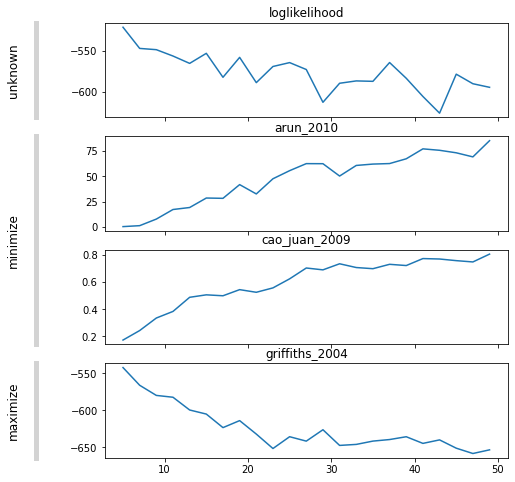

In [ ]:
eval_results_by_topics = results_by_parameter(eval_results, 'n_topics')
plot_eval_results(eval_results_by_topics);

In [ ]:
eval_results_by_topics[0][1]['griffiths_2004'] # 1. list position 2. #topics or dictionary 3. dictionary keys

-7412736.731466592

In [ ]:
# Save results into dataframe
topic_number = []
griffiths_values = []
loglikelihood_values = []
arun_values = []
caojuan_values = []

for index in range(len(eval_results_by_topics)):
  topic_number.append(eval_results_by_topics[index][0]) # topics
  griffiths_values.append(eval_results_by_topics[index][1]['griffiths_2004']) 
  loglikelihood_values.append(eval_results_by_topics[index][1]['loglikelihood']) 
  arun_values.append(eval_results_by_topics[index][1]['arun_2010']) 
  caojuan_values.append(eval_results_by_topics[index][1]['cao_juan_2009']) 
print(len(eval_results_by_topics))
print(len(griffiths_values))
print(len(loglikelihood_values))
print(len(arun_values))
print(len(caojuan_values))
print(len(topic_number))

23
23
23
23
23
23


In [ ]:
eva_dict = {'topic_number':topic_number,'griffiths_2004':griffiths_values,\
            'loglikelihood':loglikelihood_values,'arun_2010':arun_values,\
            'cao_juan_2009':caojuan_values}
eva_df = pd.DataFrame.from_dict(eva_dict)

In [ ]:
eva_df.to_csv('Evaluation_results.csv')

In [ ]:
# Get position of max Griffiths value
m = max(griffiths_values)
[i for i, j in enumerate(griffiths_values) if j == m]

[0]

In [ ]:
# Max value is at the beginning, therefore we need the 2nd max
def second_largest(numbers):
    count = 0
    m1 = m2 = float('-inf')
    for x in numbers:
        count += 1
        if x > m2:
            if x >= m1:
                m1, m2 = x, m1            
            else:
                m2 = x
    return m2 if count >= 2 else None

second_largest(griffiths_values)

-992904.4684769951

In [ ]:
sorted_griffiths = sorted(griffiths_values)
sorted_griffiths

[-1022851.9861853805,
 -1019707.4586032388,
 -1017223.0715529202,
 -1015315.9620970542,
 -1009460.1294286533,
 -1006672.8469809955,
 -1006467.5619987079,
 -1006139.7095763459,
 -1005856.0921761357,
 -1005837.6516960559,
 -1005769.8428994749,
 -1004717.3171973203,
 -1004283.2198950523,
 -1003974.1945041585,
 -1002870.4019329102,
 -1002678.4985005105,
 -1002155.9887679208,
 -999457.0575179947,
 -996733.9403770274,
 -995934.0929372977,
 -993498.2766845428,
 -992904.4684769951,
 -992662.8822100853]

In [ ]:
#print(griffiths_values.index(-995934.0929372977))
print(griffiths_values[0])
print(topic_number[0])

-3221.7368234835862
5


In [ ]:
# Save evaluation object for future reference

def save_object(obj, filename):
    with open(filename, 'wb') as output:  # Overwrites any existing file.
        pickle.dump(obj, output, pickle.HIGHEST_PROTOCOL)

# sample usage
save_object(eval_results, 'detailed_evaluation_results.pkl')
save_object(eval_results_by_topics, 'evaluation_results.pkl')

# LDA Model

In [ ]:
def print_topics(model, vectorizer, n_top_words): # Function to print the top words in each topic
    words = vectorizer.get_feature_names() # Get the words from the Corpus
    Topics_lexica = list()
    Word_topic_probability = list()
    for topic_idx, topic in enumerate(model.components_):
        ### Uncomment if you want to display the top words by each topic
        #print('\nTopic #%d:' % topic_idx)
        #print(' '.join([words[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))
        Topic_word = [words[i] for i in topic.argsort()[::-1]]
        Probability_word = np.sort(topic)[::-1] /np.sum(topic)
        Word_topic_probability.append(Probability_word) 
        Topics_lexica.append(Topic_word)
    return Topics_lexica, Word_topic_probability

# Get DTM
cv = CountVectorizer()
data_cv = cv.fit_transform(Data_Frame['abstract_without_stopwords'])

# # L D A  M O D E L
n_components = 5 #topics
n_top_words = 30
alpha = None
eta = None
columns = cv.get_feature_names()

lda = LatentDirichletAllocation(n_components=n_components, max_iter=80,
                                learning_method='batch',
                                learning_offset=50.,
                                random_state=0,
                                doc_topic_prior=alpha,
                                topic_word_prior=eta)

lda.fit(data_cv)
Topic_Probability = lda.transform(data_cv)
Topics_Lexica, Words_Probability = print_topics(lda,cv,n_top_words)

#open_file = open("2020_Stop_Fixed_Topic_Probability.pkl", "wb")
#pickle.dump(Topic_Probability, open_file)

In [ ]:
np.shape(Topic_Probability)

(1, 5)

In [ ]:
np.savetxt("2020_Stop_Fixed_Topic_Probability.csv", Topic_Probability, delimiter=",")

Topics words saved


ValueError: ignored

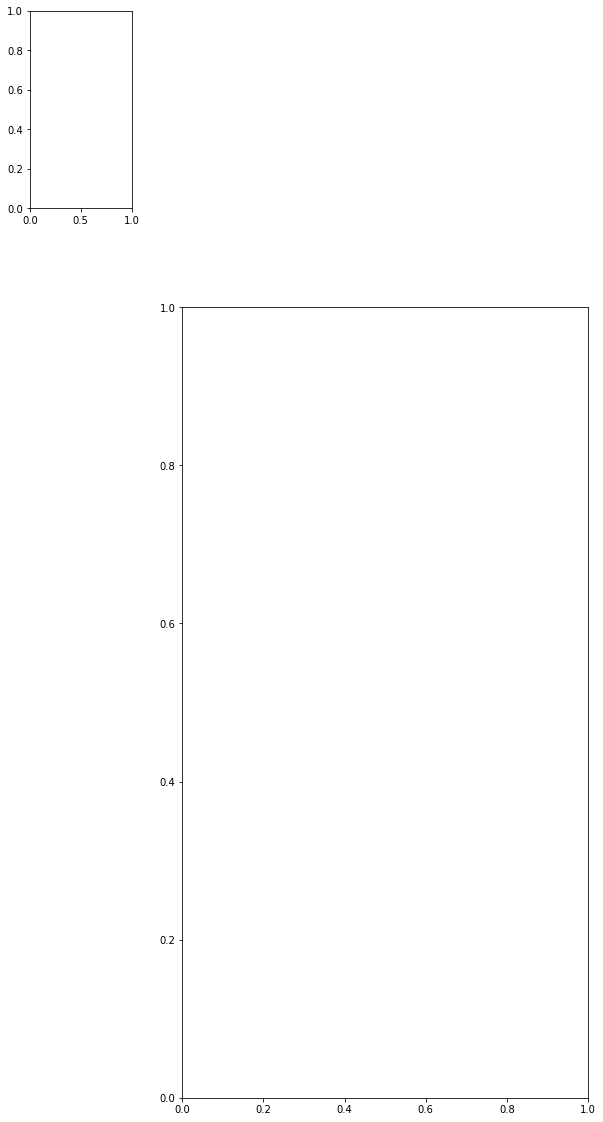

In [ ]:
# # R E S U L T S
concept = 'connectomics'
PATH_topics = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/LDA_Results/Topic_Lexica/2005_05_Topics_Lexica/"

for k in range (0, len(Topics_Lexica)):
    Topic_Information = list(zip(Topics_Lexica[k], Words_Probability[k])) # Concatenate words and its topic probability 
    #np.savetxt(PATH_topics + 'Topic_' + str(k) + '_words.txt', Topic_Information, fmt = '%s', delimiter = '\t')
print('Topics words saved')

sns_plot = sns.clustermap(Topic_Probability, method = 'complete', metric = 'braycurtis', figsize=(10,20))
sns_plot.cax.remove()
plt.show()
#sns_plot.savefig(PATH_topics + str(n_components) + '_topics_distribution.png')

# Cicle

In [ ]:
# Directories
folder_path = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Metadata"
metadata_filenames = os.listdir(folder_path)
metadata_filenames = [x for x in metadata_filenames if ".ipynb_checkpoints" not in x]
metadata_filenames.sort(key=lambda x: int(''.join(filter(str.isdigit, x))))
metadata_filenames

['Metadata_2005.csv',
 'Metadata_2008.csv',
 'Metadata_2009.csv',
 'Metadata_2010.csv',
 'Metadata_2011.csv',
 'Metadata_2012.csv',
 'Metadata_2013.csv',
 'Metadata_2014.csv',
 'Metadata_2015.csv',
 'Metadata_2016.csv',
 'Metadata_2017.csv',
 'Metadata_2018.csv',
 'Metadata_2019.csv',
 'Metadata_2020.csv',
 'Metadata_2021_raw.csv',
 'Metadata_2021.csv']

In [ ]:
cv = CountVectorizer()
scene = "Clean_Variable"
approach = "abstract_without_stopwords" # With or without stopwords
SWFixed = 49
woSWFixed = 41
SWVariable = [5,5,9,25,41,43,43,31,31,33,31,47,43,49] # 2005-2020
woSWVariable = [5,5,7,21,23,45,41,43,49,43,29,47,45,41] # 2008-2020
Path_results = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/" + scene + "/LDA_Results/Doc_Topic_Matrices/"
year_list = [2005,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020]
for index in range(0,len(metadata_filenames)-2):
  filename = folder_path + "/" + metadata_filenames[index]
  print(filename)
  year = year_list[index]
  print(year)
  Data_Frame = pd.read_csv(filename,index_col=0)
  nTopic= woSWVariable[index]
  data_cv = cv.fit_transform(Data_Frame[approach]) # sparse matrix
  # # L D A  M O D E L
  n_components = nTopic #topics
  n_top_words = 30
  alpha = None
  eta = None
  columns = cv.get_feature_names()

  lda = LatentDirichletAllocation(n_components=n_components, max_iter=80,
                                learning_method='batch',
                                learning_offset=50.,
                                random_state=0,
                                doc_topic_prior=alpha,
                                topic_word_prior=eta)

  lda.fit(data_cv)
  Topic_Probability = lda.transform(data_cv)
  # Save objects
  #open_file = open(str(year) + "_Topic_Probability.pkl", "wb")
  #pickle.dump(Topic_Probability, open_file)
  #open_file.close()
  np.savetxt(Path_results + str(year) + "_Topic_Probability.csv", Topic_Probability, delimiter=",")
  print("Year " + str(year) + " topic probability shape is " + str(Topic_Probability.shape))

/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Metadata/Metadata_2005.csv
2005
Year 2005 topic probability shape is (1, 5)
/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Metadata/Metadata_2008.csv
2008
Year 2008 topic probability shape is (4, 5)
/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Metadata/Metadata_2009.csv
2009
Year 2009 topic probability shape is (14, 7)
/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Metadata/Metadata_2010.csv
2010
Year 2010 topic probability shape is (44, 21)
/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Metadata/Metadata_2011.csv
2011
Year 2011 topic probability shape is (117, 23)
/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Metadata/Metadata_2012.csv
2012
Year 2012 topic probability shape is (283, 45)
/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Metadata/Metadata_2013.csv
2013
Year 2013 topic probability shape is (685, 41)
/content/drive/MyDrive/semantic_brow

# Jensen-Shannon

In [ ]:
js_matrix = distance.pdist(Topic_Probability, metric='jensenshannon')
js_matrix = distance.squareform(js_matrix)

In [ ]:
print(np.shape(js_matrix))

(1, 1)


In [ ]:
# # R E S U L T S
PATH_jsmatrix = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed/Connectomics/"\
                "Year_2005/Results/With_Stopwords/"
# Save Numpy array to txt
np.savetxt(PATH_jsmatrix + 'JS_' + str(n_components) + '_Topics_2005.txt', js_matrix, delimiter=',', fmt='%1.5f')

---
# Without Stopwords
---

# Run LDA Evaluation

In [ ]:
# Get DTM
data_cv_stopwords = cv.fit_transform(Data_Frame['abstract_without_stopwords'])
# Evaluation's parameters definition
var_params = [{'n_topics': k, 'alpha': 1/k} for k in range(5, 50, 2)]
const_params = {
    'n_iter': 1000,
    'eta': 0.1,       # "eta" aka "beta"
    'random_state': 20191122  # to make results reproducible
}
# Evaluation results
eval_results = evaluate_topic_models(data_cv_stopwords,
                                     varying_parameters=var_params,
                                     constant_parameters=const_params,
                                     return_models=True,
                                     metric=['arun_2010','cao_juan_2009',
                                             'griffiths_2004','loglikelihood'])

INFO:lda:n_documents: 1
INFO:lda:n_documents: 1
INFO:lda:vocab_size: 41
INFO:lda:vocab_size: 41
INFO:lda:n_words: 52
INFO:lda:n_topics: 7
INFO:lda:n_iter: 1000
INFO:lda:n_words: 52
INFO:lda:n_topics: 5
INFO:lda:<0> log likelihood: -337
INFO:lda:n_iter: 1000
INFO:lda:<0> log likelihood: -323
INFO:lda:<10> log likelihood: -302
INFO:lda:<10> log likelihood: -294
INFO:lda:<20> log likelihood: -297
INFO:lda:<20> log likelihood: -295
INFO:lda:<30> log likelihood: -311
INFO:lda:<30> log likelihood: -297
INFO:lda:<40> log likelihood: -308
INFO:lda:<40> log likelihood: -300
INFO:lda:<50> log likelihood: -316
INFO:lda:<50> log likelihood: -300
INFO:lda:<60> log likelihood: -309
INFO:lda:<60> log likelihood: -293
INFO:lda:<70> log likelihood: -298
INFO:lda:<70> log likelihood: -292
INFO:lda:<80> log likelihood: -292
INFO:lda:<90> log likelihood: -302
INFO:lda:<80> log likelihood: -290
INFO:lda:<100> log likelihood: -305
INFO:lda:<90> log likelihood: -295
INFO:lda:<110> log likelihood: -317
INFO:l

KeyboardInterrupt: ignored

# LDA Evaluation

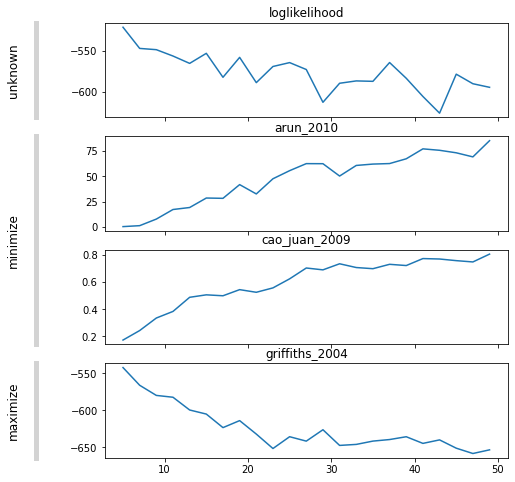

In [ ]:
eval_results_by_topics = results_by_parameter(eval_results, 'n_topics')
plot_eval_results(eval_results_by_topics);

In [ ]:
# Save results into dataframe
topic_number = []
griffiths_values = []
loglikelihood_values = []
arun_values = []
caojuan_values = []

for index in range(len(eval_results_by_topics)):
  topic_number.append(eval_results_by_topics[index][0]) # topics
  griffiths_values.append(eval_results_by_topics[index][1]['griffiths_2004']) 
  loglikelihood_values.append(eval_results_by_topics[index][1]['loglikelihood']) 
  arun_values.append(eval_results_by_topics[index][1]['arun_2010']) 
  caojuan_values.append(eval_results_by_topics[index][1]['cao_juan_2009']) 
print(len(eval_results_by_topics))
print(len(griffiths_values))
print(len(loglikelihood_values))
print(len(arun_values))
print(len(caojuan_values))
print(len(topic_number))

23
23
23
23
23
23


In [ ]:
eva_dict = {'topic_number':topic_number,'griffiths_2004':griffiths_values,\
            'loglikelihood':loglikelihood_values,'arun_2010':arun_values,\
            'cao_juan_2009':caojuan_values}
eva_df = pd.DataFrame.from_dict(eva_dict)
eva_df.to_csv('Evaluation_results_wostopwords.csv')

In [ ]:
# Get position of max Griffiths value
m = max(griffiths_values)
[i for i, j in enumerate(griffiths_values) if j == m]

[0]

In [ ]:
# Max value is at the beginning, therefore we need the 2nd max
def second_largest(numbers):
    count = 0
    m1 = m2 = float('-inf')
    for x in numbers:
        count += 1
        if x > m2:
            if x >= m1:
                m1, m2 = x, m1            
            else:
                m2 = x
    return m2 if count >= 2 else None

second_largest(griffiths_values)

-690930.2066105672

In [ ]:
#print(griffiths_values.index(-690930.2066105672))
print(eva_df['griffiths_2004'][0])
print(eva_df['topic_number'][0])

-1809.6908464565695
5


In [ ]:
# Save evaluation object for future reference

def save_object(obj, filename):
    with open(filename, 'wb') as output:  # Overwrites any existing file.
        pickle.dump(obj, output, pickle.HIGHEST_PROTOCOL)

# sample usage
save_object(eval_results, 'detailed_evaluation_results_wostopwords.pkl')
save_object(eval_results_by_topics, 'evaluation_results_wostopwords.pkl')

# LDA Model

In [ ]:
def print_topics(model, vectorizer, n_top_words): # Function to print the top words in each topic
    words = vectorizer.get_feature_names() # Get the words from the Corpus
    Topics_lexica = list()
    Word_topic_probability = list()
    for topic_idx, topic in enumerate(model.components_):
        ### Uncomment if you want to display the top words by each topic
        #print('\nTopic #%d:' % topic_idx)
        #print(' '.join([words[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))
        Topic_word = [words[i] for i in topic.argsort()[::-1]]
        Probability_word = np.sort(topic)[::-1] /np.sum(topic)
        Word_topic_probability.append(Probability_word) 
        Topics_lexica.append(Topic_word)
    return Topics_lexica, Word_topic_probability

# Get DTM
cv = CountVectorizer()
data_cv_stopwords = cv.fit_transform(Data_Frame['abstract_without_stopwords'])

# # L D A  M O D E L
n_components = 5
n_top_words = 30
alpha = None
eta = None
columns = cv.get_feature_names()

lda = LatentDirichletAllocation(n_components=n_components, max_iter=80,
                                learning_method='batch',
                                learning_offset=50,
                                random_state=0,
                                doc_topic_prior=alpha,
                                topic_word_prior=eta)
lda.fit(data_cv_stopwords)
Topic_Probability = lda.transform(data_cv_stopwords)
Topics_Lexica, Words_Probability = print_topics(lda,cv,n_top_words)

Topics words saved


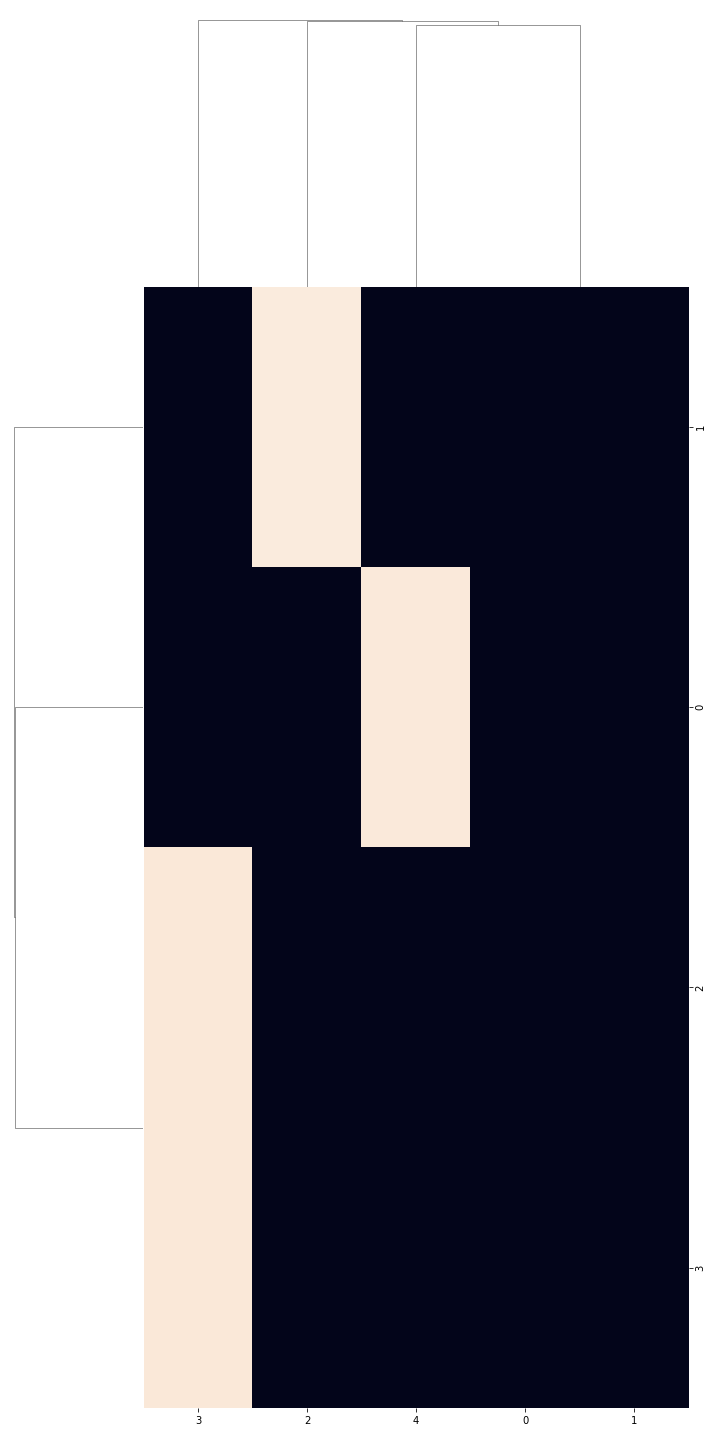

In [ ]:
# # R E S U L T S
concept = 'connectomics'
PATH_topics = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed/Connectomics/"\
                "Year_2008/Results/Without_Stopwords/05_Topics_Lexica/"

for k in range (0, len(Topics_Lexica)):
    Topic_Information = list(zip(Topics_Lexica[k], Words_Probability[k])) # Concatenate words and its topic probability 
    np.savetxt(PATH_topics + 'Topic_' + str(k) + '_words_wostopwords.txt', Topic_Information, fmt = '%s', delimiter = '\t')
print('Topics words saved')


sns_plot = sns.clustermap(Topic_Probability, method = 'complete', metric = 'braycurtis', figsize=(10,20))
sns_plot.cax.remove()
plt.show()
sns_plot.savefig(PATH_topics + str(n_components) + '_topics_distribution_wostopwords.png')

# Jensen-Shannon

In [ ]:
# # G E T  M A T R I X
js_matrix_wo = distance.pdist(Topic_Probability, metric='jensenshannon')
js_matrix_wo = distance.squareform(js_matrix_wo)

In [ ]:
print(np.shape(js_matrix_wo))

(4, 4)


In [ ]:
# # R E S U L T S
PATH_jsmatrix = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed/Connectomics/"\
                "Year_2008/Results/Without_Stopwords/"
# Save Numpy array to txt
np.savetxt(PATH_jsmatrix + 'JS_' + str(n_components) + '_Topics_2008_wostopwords.txt', js_matrix_wo, delimiter=',', fmt='%1.5f')

# Papers to JSON file 11-12-2020


In [ ]:
# Save papers (list of dictionaries) as json file
with open('Papers_' + str(concept) + '.json', 'w', encoding='utf-8') as f:
    json.dump(papers['PubmedArticle'], f, ensure_ascii=False, indent=4)

In [ ]:
# Opening JSON file 
papers_file = []
with open("/content/drive/MyDrive/semantic_browser/NLP_Pubmed/Connectomics"\
          "/Year_2020/Metadata/Papers_details.json") as json_file: 
    papers_file = json.load(json_file) 
  
    # Print the type of data variable 
    print("Type:", type(papers_file))
    # Print the length of data variable 
    print("Length:", len(papers_file))

Type: <class 'list'>
Length: 6284


In [ ]:
papers_file[5860]

{'MedlineCitation': {'Article': {'ArticleDate': [],
   'ArticleTitle': 'Reply: A transvenous pressure gradient mechanism behind ventriculomegaly.',
   'AuthorList': [{'AffiliationInfo': [{'Affiliation': 'Department of Psychiatry, Kyoto University Graduate School of Medicine, Kyoto, Japan.',
       'Identifier': []},
      {'Affiliation': 'Laboratory for Brain Connectomics Imaging, RIKEN Center for Biosystems Dynamics Research, Kobe, Japan.',
       'Identifier': []},
      {'Affiliation': 'Human Brain Research Center, Kyoto University Graduate School of Medicine, Kyoto, Japan.',
       'Identifier': []}],
     'ForeName': 'Toshihiko',
     'Identifier': [],
     'Initials': 'T',
     'LastName': 'Aso'},
    {'AffiliationInfo': [{'Affiliation': 'Department of Psychiatry, Kyoto University Graduate School of Medicine, Kyoto, Japan.',
       'Identifier': []},
      {'Affiliation': 'Department of Psychiatry and Behavioral Sciences, Graduate School of Medical and Dental Sciences, Tokyo Medi

# Bibliography

* JSON file: https://www.geeksforgeeks.org/convert-json-to-dictionary-in-python/